# Classification Results
Results-only viewer — no training code. All models were trained via `src/models/` scripts.
Run cells top-to-bottom from the project root.

In [6]:
import glob
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT    = os.path.abspath(os.path.join(os.getcwd(), '..'))
METRICS = os.path.join(ROOT, 'outputs', 'metrics')
FIGURES = os.path.join(ROOT, 'outputs', 'figures')

def latest(pattern):
    """Return the most recently modified file matching a glob pattern."""
    files = sorted(glob.glob(pattern), key=os.path.getmtime)
    if not files:
        raise FileNotFoundError(f'No file matching: {pattern}')
    return files[-1]

## 1. Class Distribution

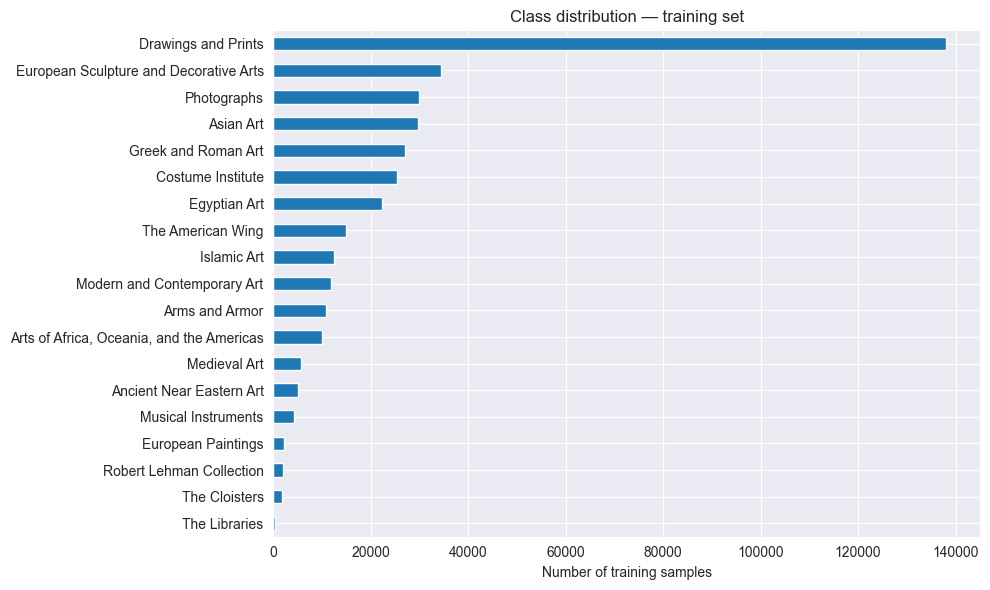

Saved → /Users/ishan/Documents/Northeastern/Spring 2026/Machine Learning/Final project/cultural-pattern-discovery-ml/outputs/figures/class_distribution.png


In [7]:
y_train = np.load(os.path.join(ROOT, 'data', 'processed', 'y_train.npy'))
le      = joblib.load(os.path.join(ROOT, 'models', 'label_encoder.joblib'))

counts = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='barh', ax=ax)
ax.set_xlabel('Number of training samples')
ax.set_title('Class distribution — training set')
fig.tight_layout()

out_path = os.path.join(FIGURES, 'class_distribution.png')
os.makedirs(FIGURES, exist_ok=True)
fig.savefig(out_path, dpi=150)
plt.show()
print(f'Saved → {out_path}')

## 2. Model Comparison Table

In [8]:
lr_path   = latest(os.path.join(METRICS, '*lr*report*.csv'))
rf_path   = latest(os.path.join(METRICS, '*rf*report*.csv'))
xgb_path  = latest(os.path.join(METRICS, '*xgb*report*.csv'))
mlp_path  = latest(os.path.join(METRICS, '*mlp*report*.csv'))
hier_path = latest(os.path.join(METRICS, '*hierarchical*report*.csv'))

print('Reports loaded:')
for name, p in [('LR', lr_path), ('RF', rf_path), ('XGB', xgb_path),
                ('MLP', mlp_path), ('Hierarchical', hier_path)]:
    print(f'  {name}: {os.path.basename(p)}')

AGGREGATE = {'accuracy', 'macro avg', 'weighted avg'}

def load_f1(path, col_name):
    df = pd.read_csv(path, index_col=0)
    return df.loc[~df.index.isin(AGGREGATE), 'f1-score'].rename(col_name)

comparison = pd.concat([
    load_f1(lr_path,   'LR F1'),
    load_f1(rf_path,   'RF F1'),
    load_f1(xgb_path,  'XGB F1'),
    load_f1(mlp_path,  'MLP F1'),
    load_f1(hier_path, 'Hierarchical F1'),
], axis=1).sort_values('Hierarchical F1', ascending=False)

comparison.index.name = 'Department'

def macro_avg(col):
    return pd.Series({col: comparison[col].mean()}, name='Macro Average')

summary = pd.concat([macro_avg(c) for c in comparison.columns], axis=0).to_frame().T
summary.index = ['Macro Average']
comparison_with_summary = pd.concat([comparison, summary])

out_path = os.path.join(METRICS, 'model_comparison.csv')
comparison_with_summary.to_csv(out_path)
print(f'\nSaved → {out_path}')
display(comparison_with_summary.round(4))

Reports loaded:
  LR: lr_report.csv
  RF: rf_report_20260410_230642.csv
  XGB: xgb_report_20260410_231242.csv
  MLP: mlp_report_20260411_001308.csv
  Hierarchical: hierarchical_report_20260411_002644.csv

Saved → /Users/ishan/Documents/Northeastern/Spring 2026/Machine Learning/Final project/cultural-pattern-discovery-ml/outputs/metrics/model_comparison.csv


,LR F1,RF F1,XGB F1,MLP F1,Hierarchical F1
The Libraries,0.0208,1.0000,1.0000,0.9074,1.0000
Egyptian Art,0.9687,0.9999,0.9997,0.9886,0.9996
Greek and Roman Art,0.7941,0.9934,0.9978,0.9066,0.9989
Asian Art,0.1382,0.9105,0.9917,0.8387,0.9963
Drawings and Prints,0.6166,0.9499,0.9905,0.5237,0.9959
Islamic Art,0.7555,0.9638,0.9936,0.8813,0.9953
Costume Institute,0.6855,0.9757,0.9915,0.8366,0.9941
Ancient Near Eastern Art,0.3950,0.9466,0.9904,0.6159,0.9940
Photographs,0.4102,0.9555,0.9858,0.4705,0.9913
The American Wing,0.5641,0.9545,0.9843,0.7819,0.9892


## 3. Accuracy vs Macro F1

In [9]:
summary_data = {
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP', 'Hierarchical XGBoost'],
    'Macro F1': [0.3998, 0.8669, 0.9637, 0.5892, 0.9764],
    'Accuracy': [0.5331, 0.9249, 0.9828, 0.5957, 0.9896],
}
summary_df = pd.DataFrame(summary_data).set_index('Model')
display(summary_df)

,Macro F1,Accuracy
Model,,
Logistic Regression,0.3998,0.5331
Random Forest,0.8669,0.9249
XGBoost,0.9637,0.9828
MLP,0.5892,0.5957
Hierarchical XGBoost,0.9764,0.9896


**Why macro F1 — not accuracy — is the right metric for this dataset.**

Accuracy is dominated by the largest class: Drawings and Prints alone accounts for 35 % of the test set.
A model that predicts every sample as Drawings and Prints would achieve 35 % accuracy while being
completely useless for the other 18 departments.
Macro F1 averages F1 equally across all 19 classes, giving the same weight to The Libraries (107 test
samples) as to Drawings and Prints (34,526 test samples).
This means a model must actually classify every department well to score highly — which is the correct
objective for a collection-wide tool.

## 4. Confusion Matrices


Logistic Regression — lr_confusion_matrix.png


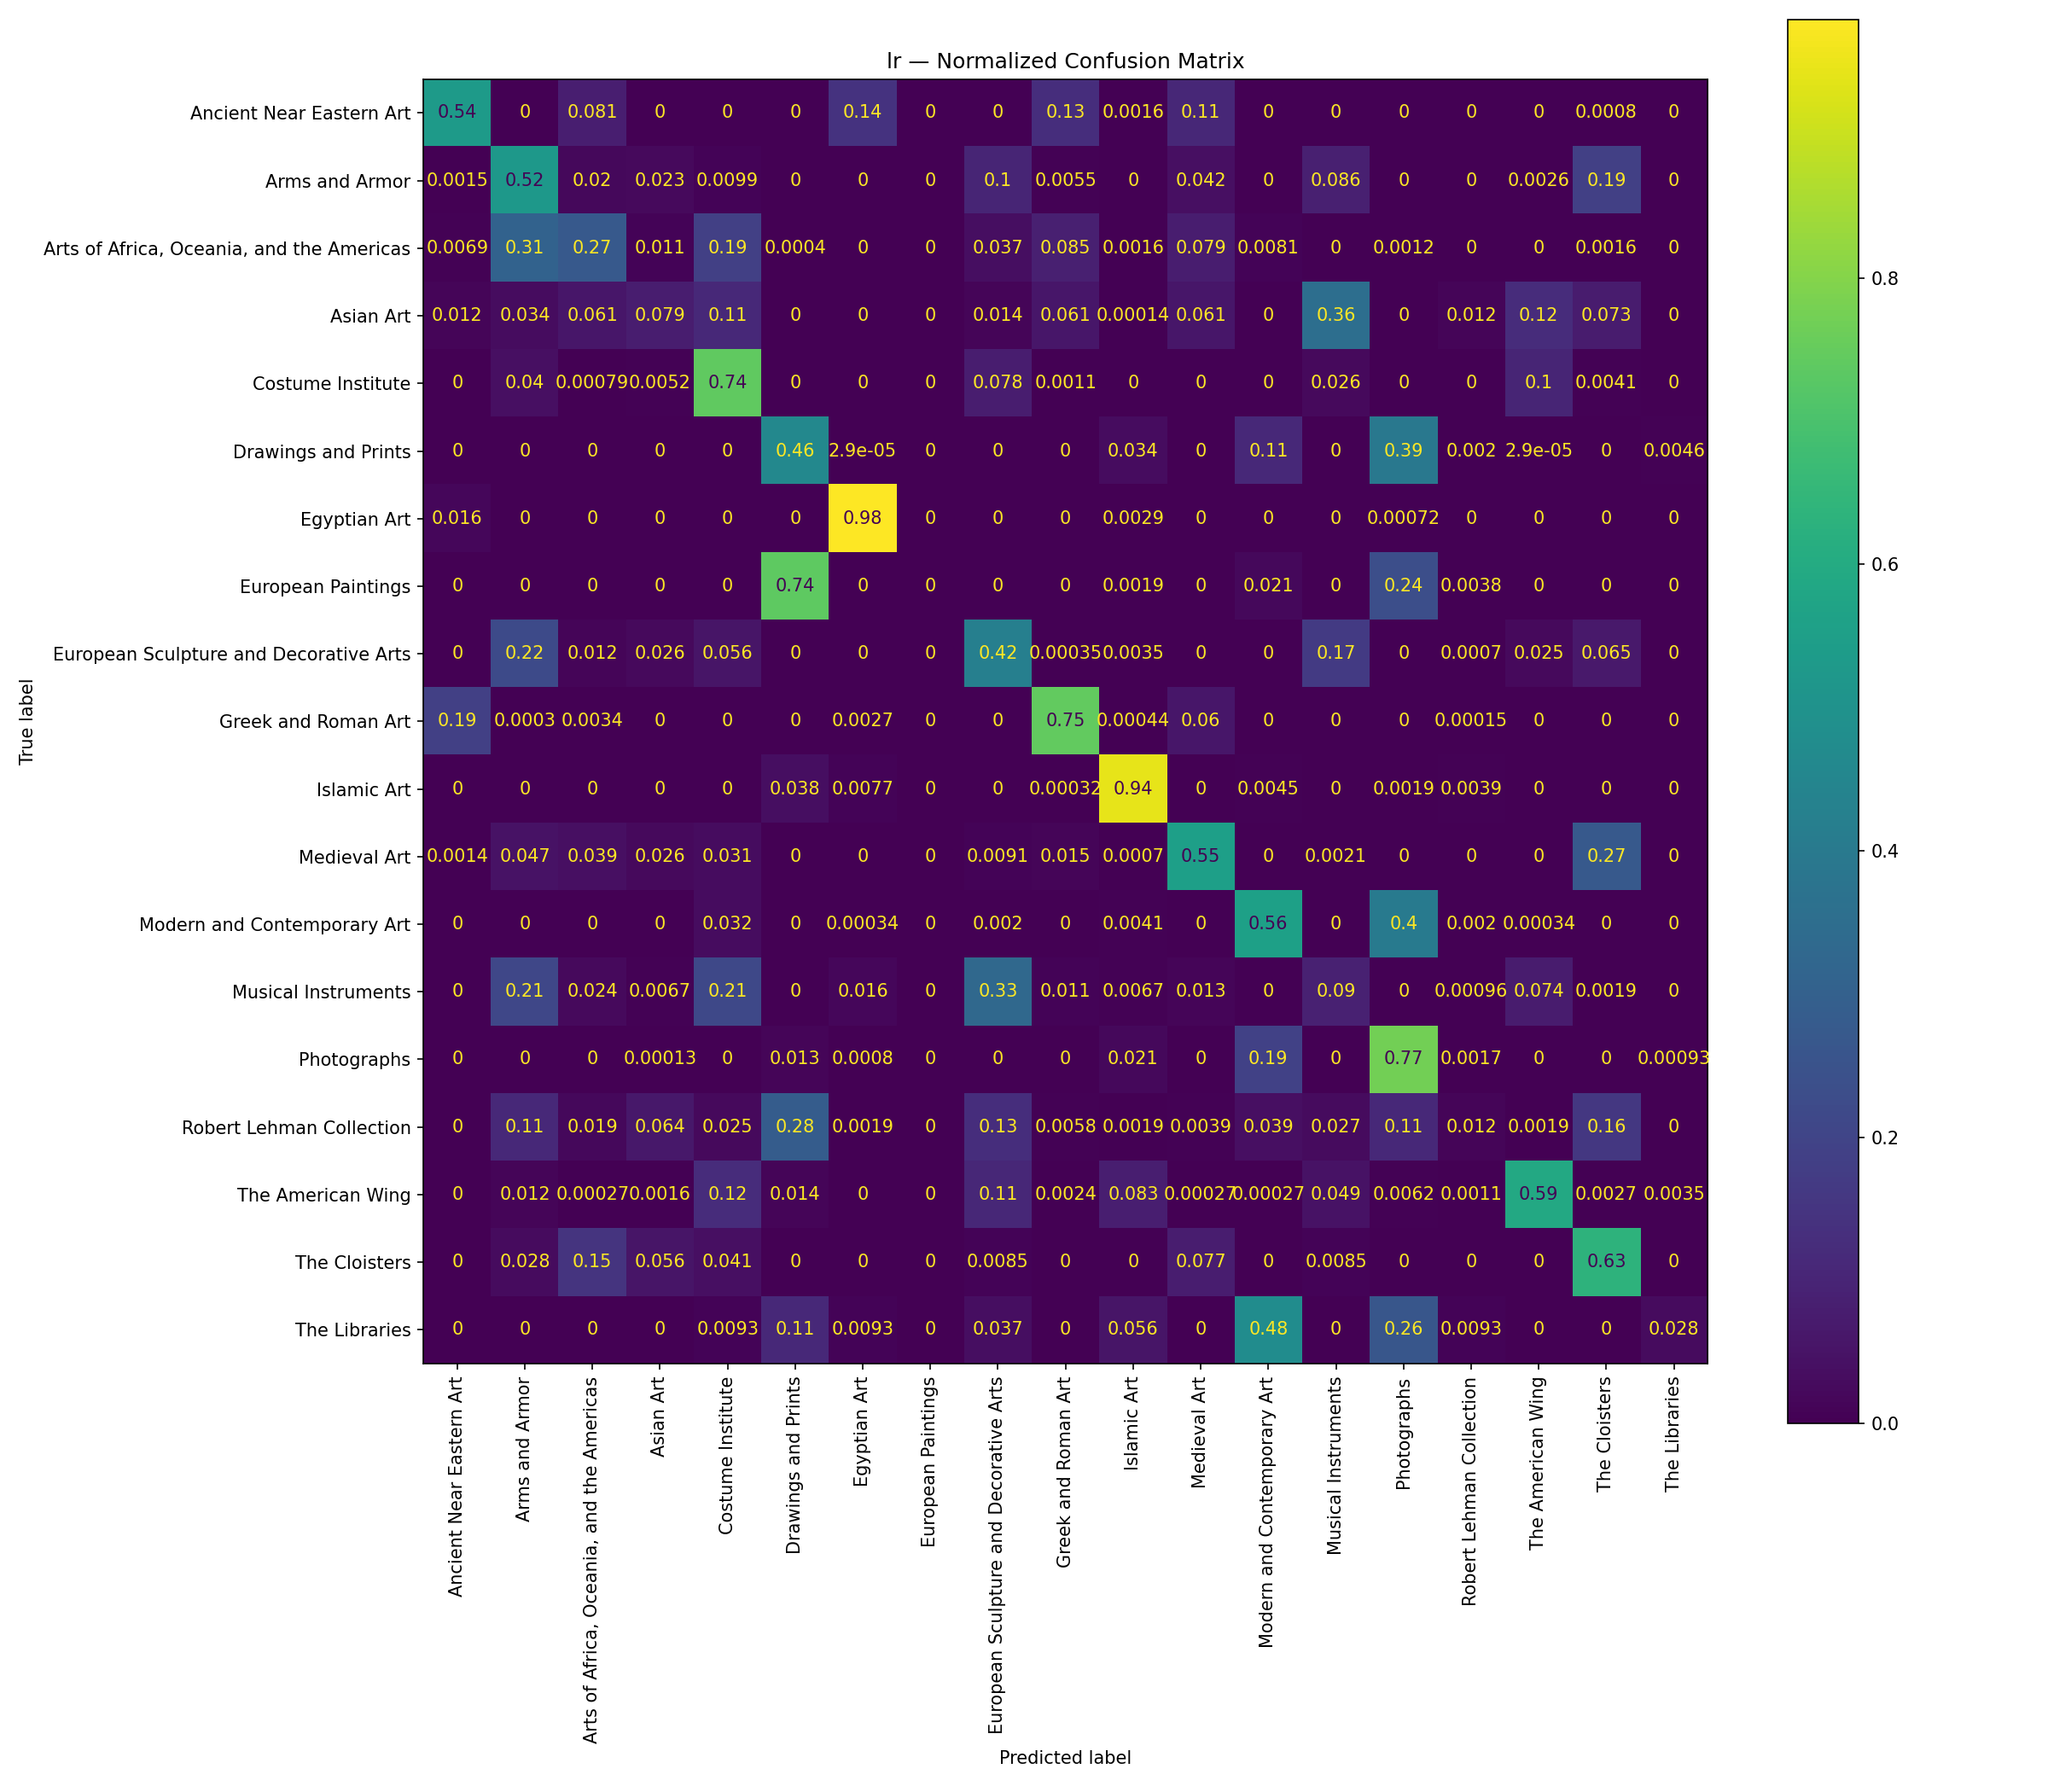


Random Forest — rf_confusion_matrix_20260410_230643.png


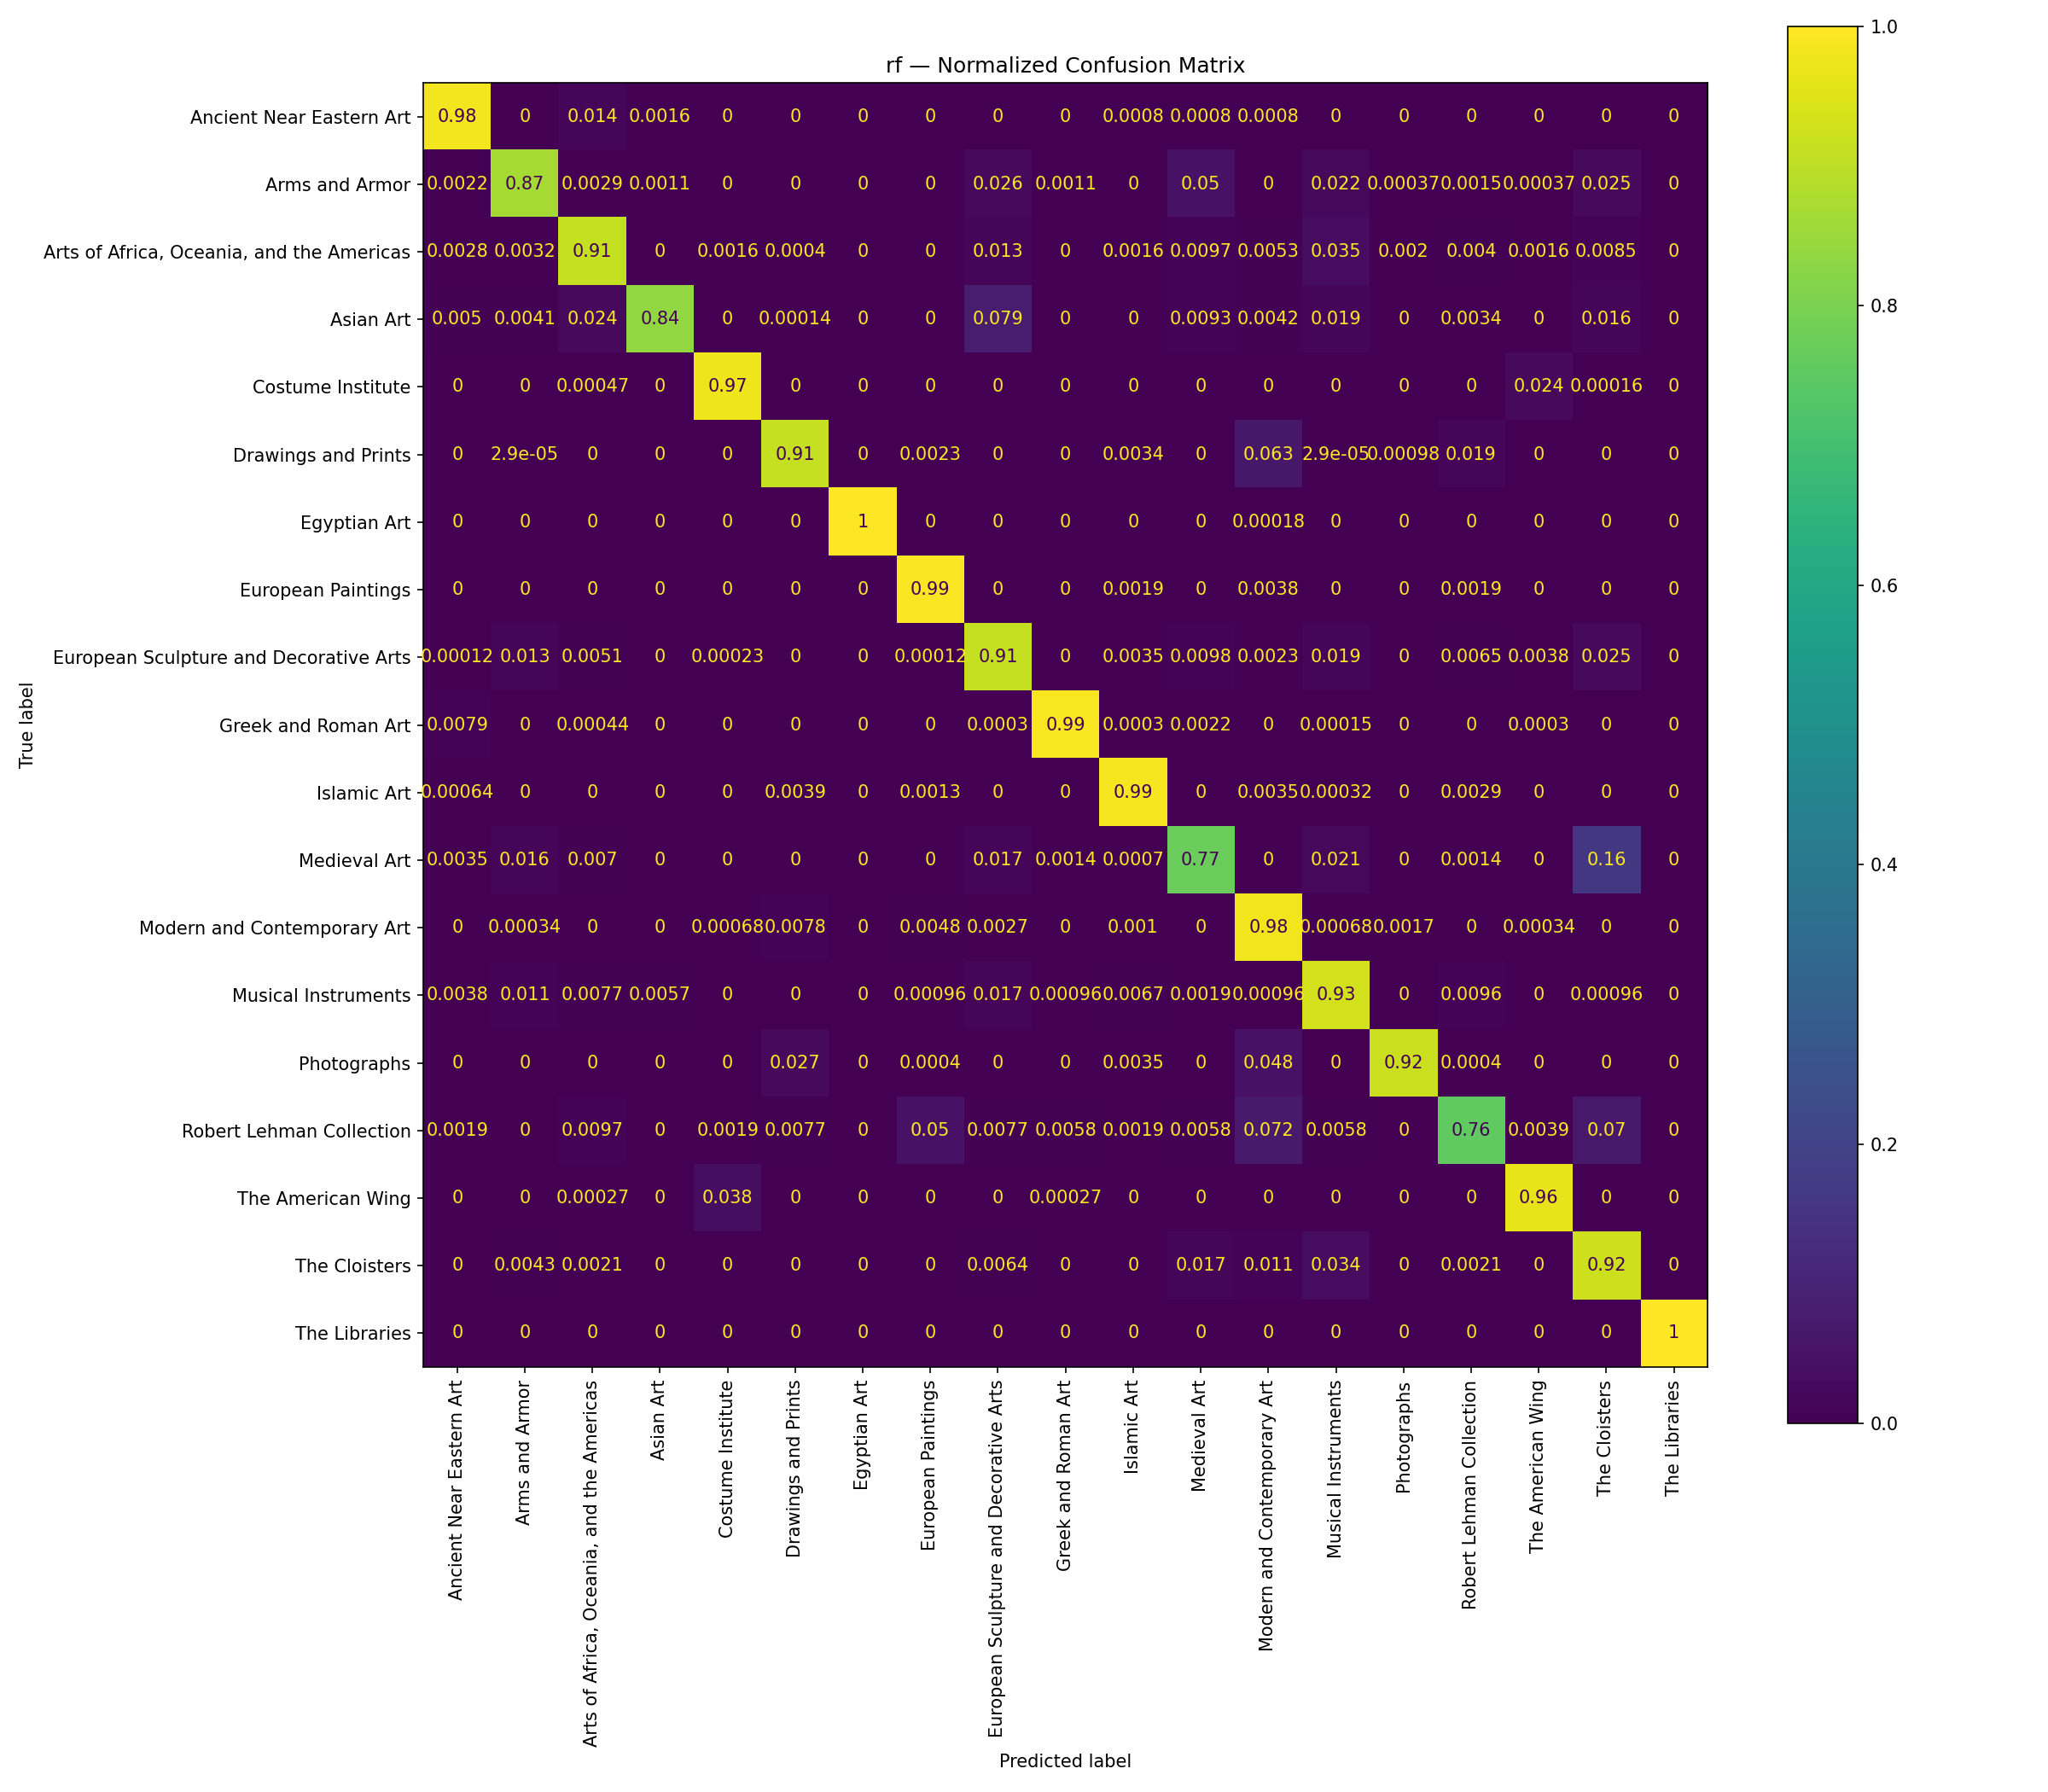


XGBoost — xgb_confusion_matrix_20260410_231242.png


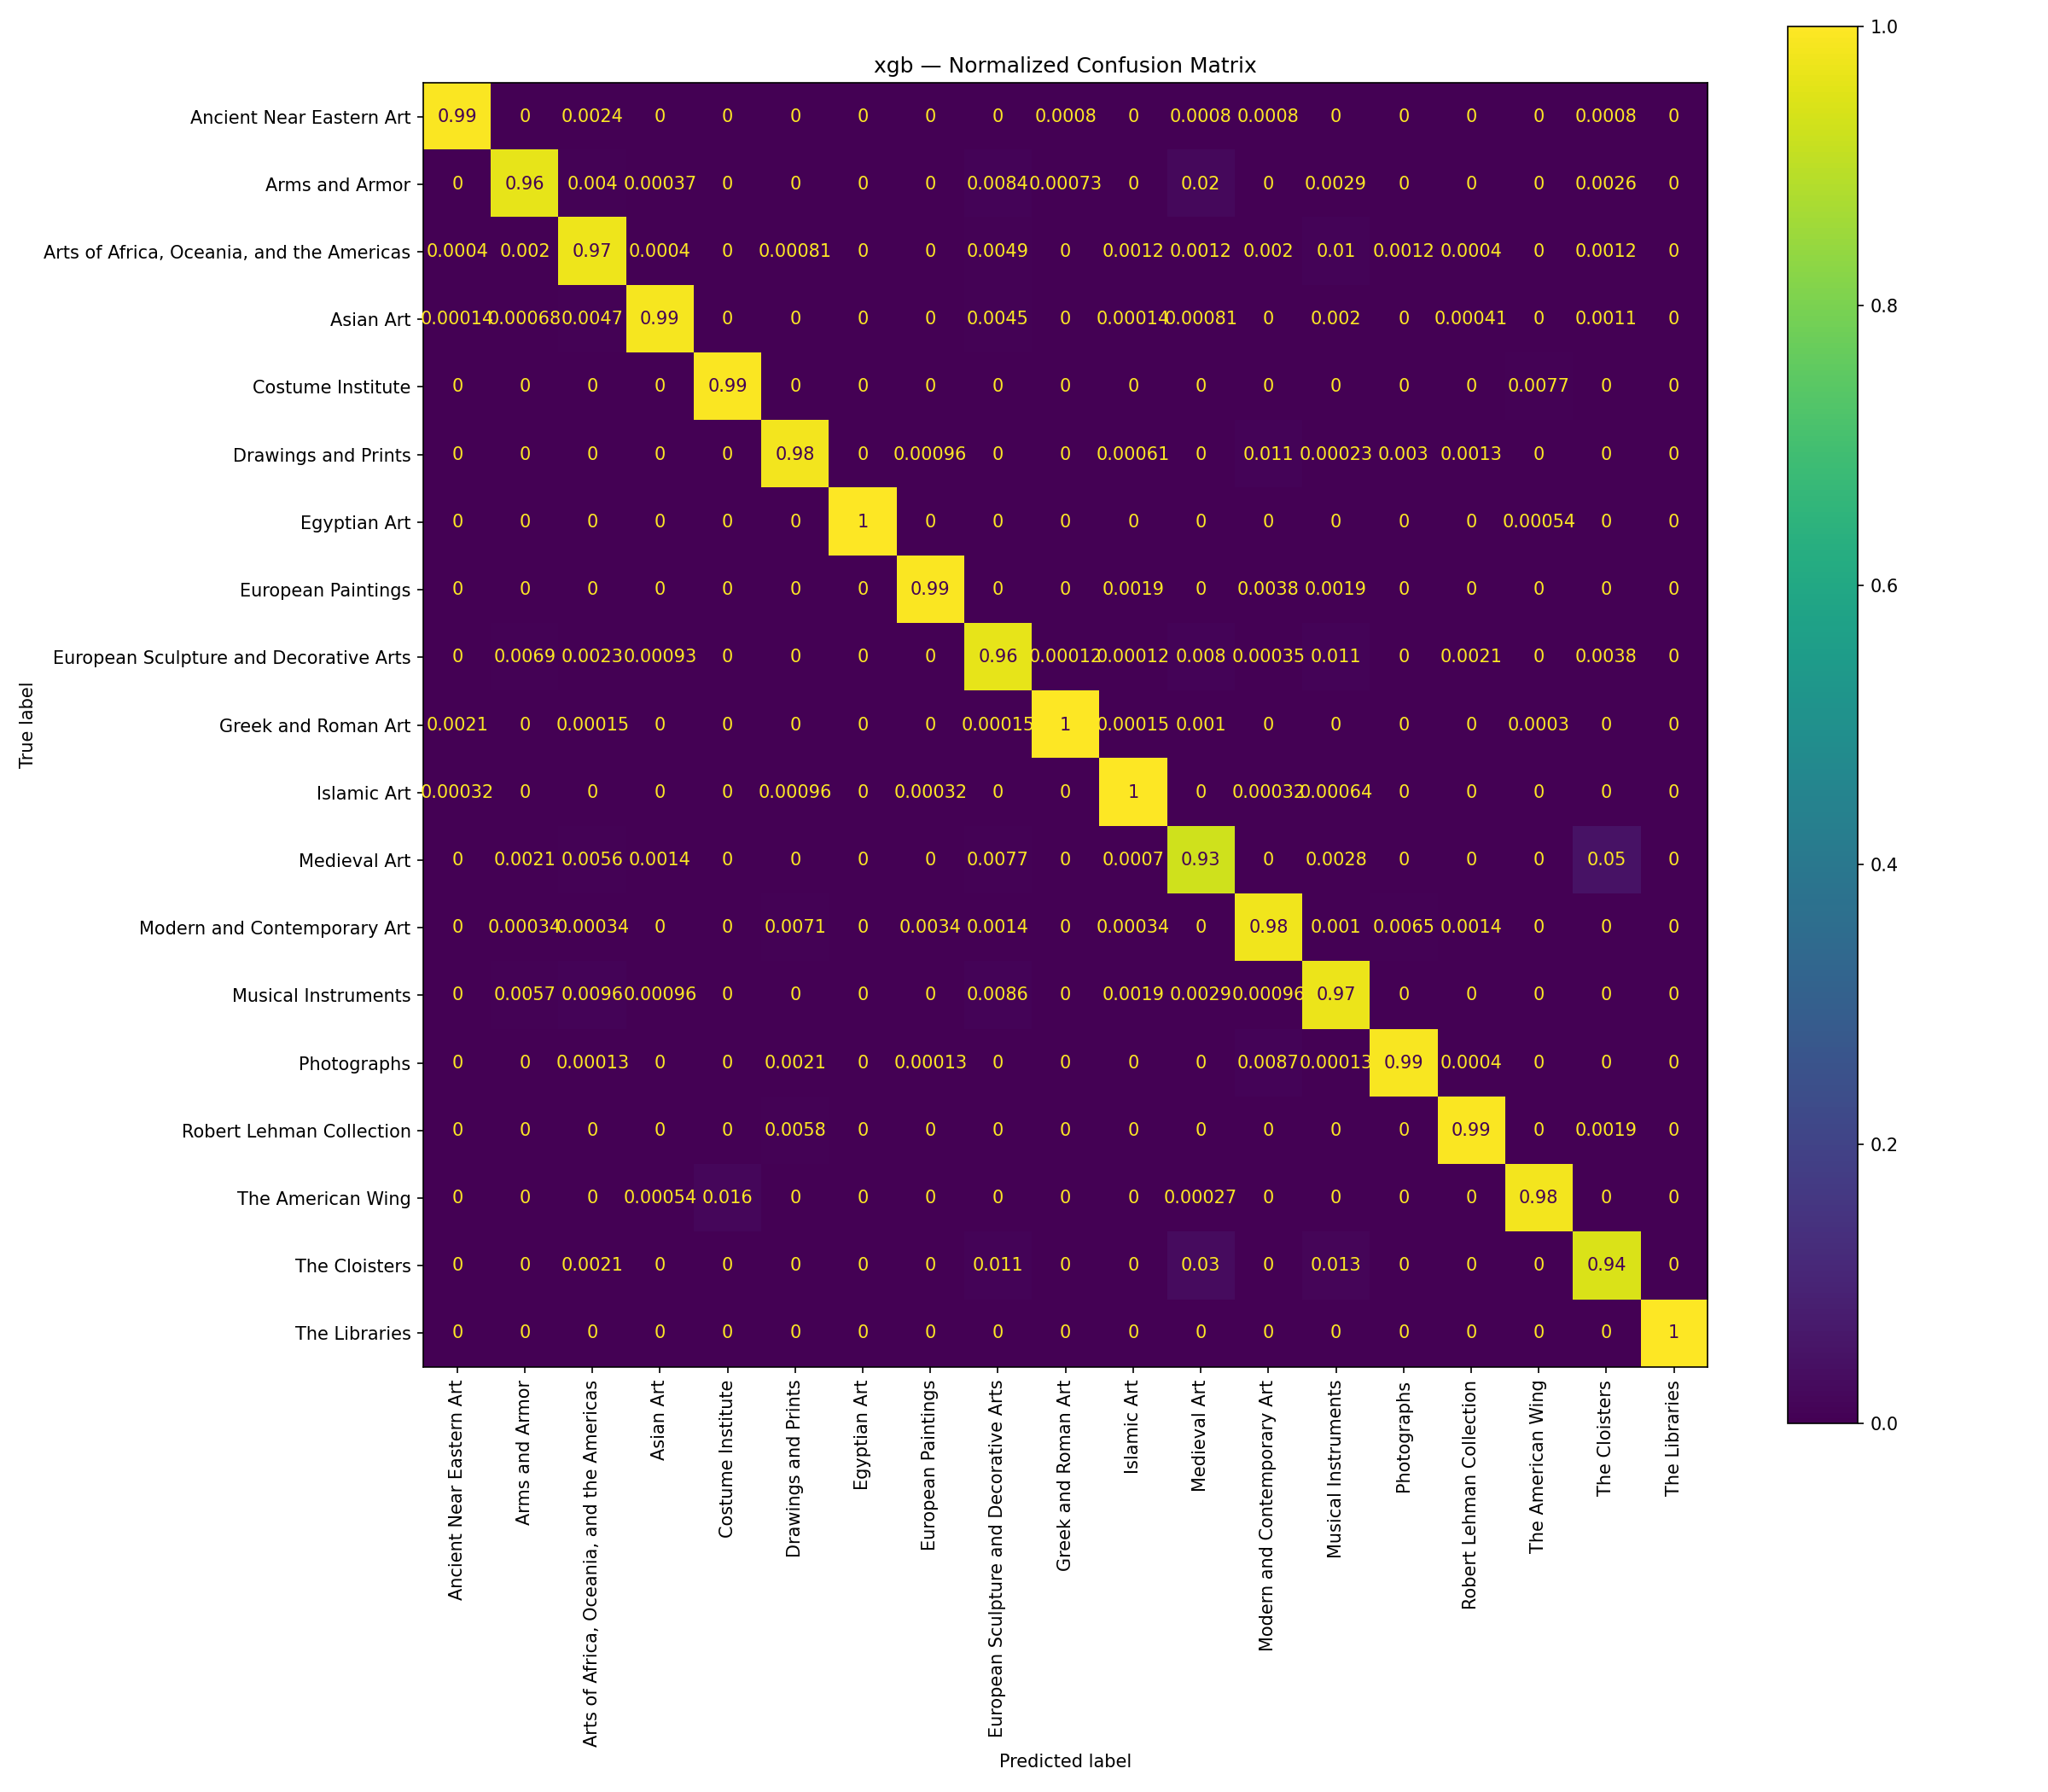


MLP — mlp_confusion_matrix_20260411_001308.png


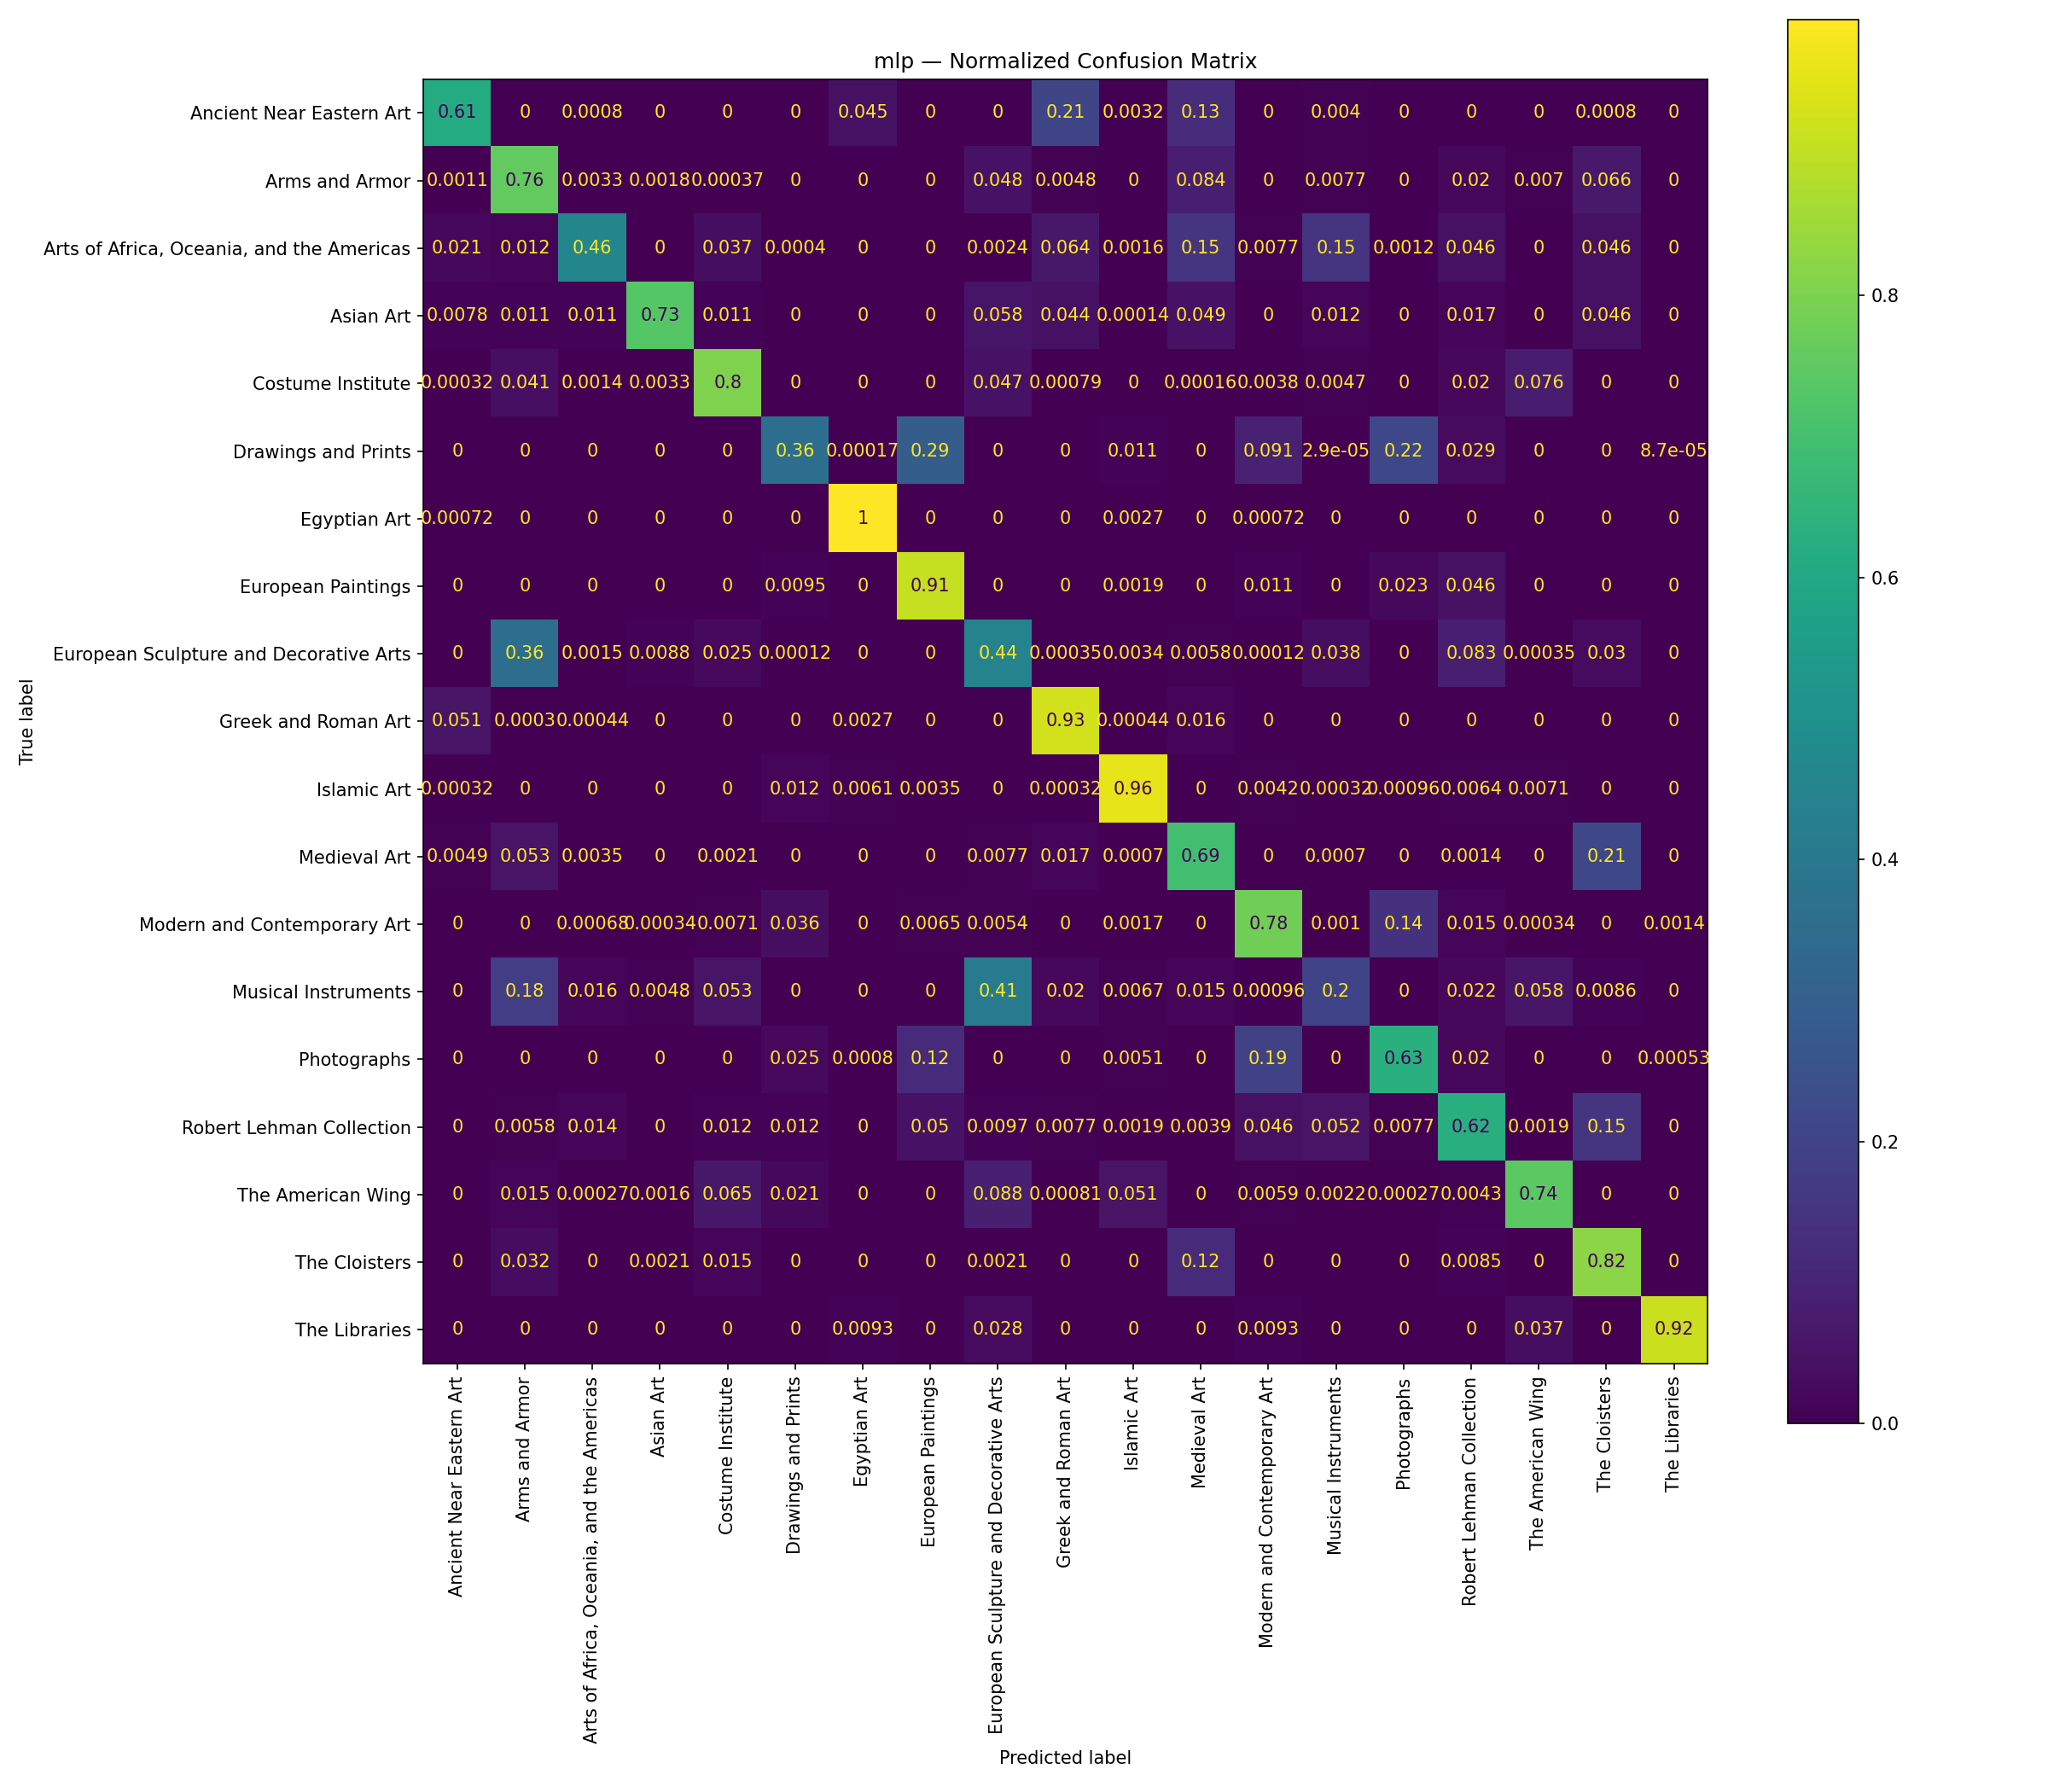


Hierarchical XGBoost — hierarchical_confusion_matrix_20260411_002645.png


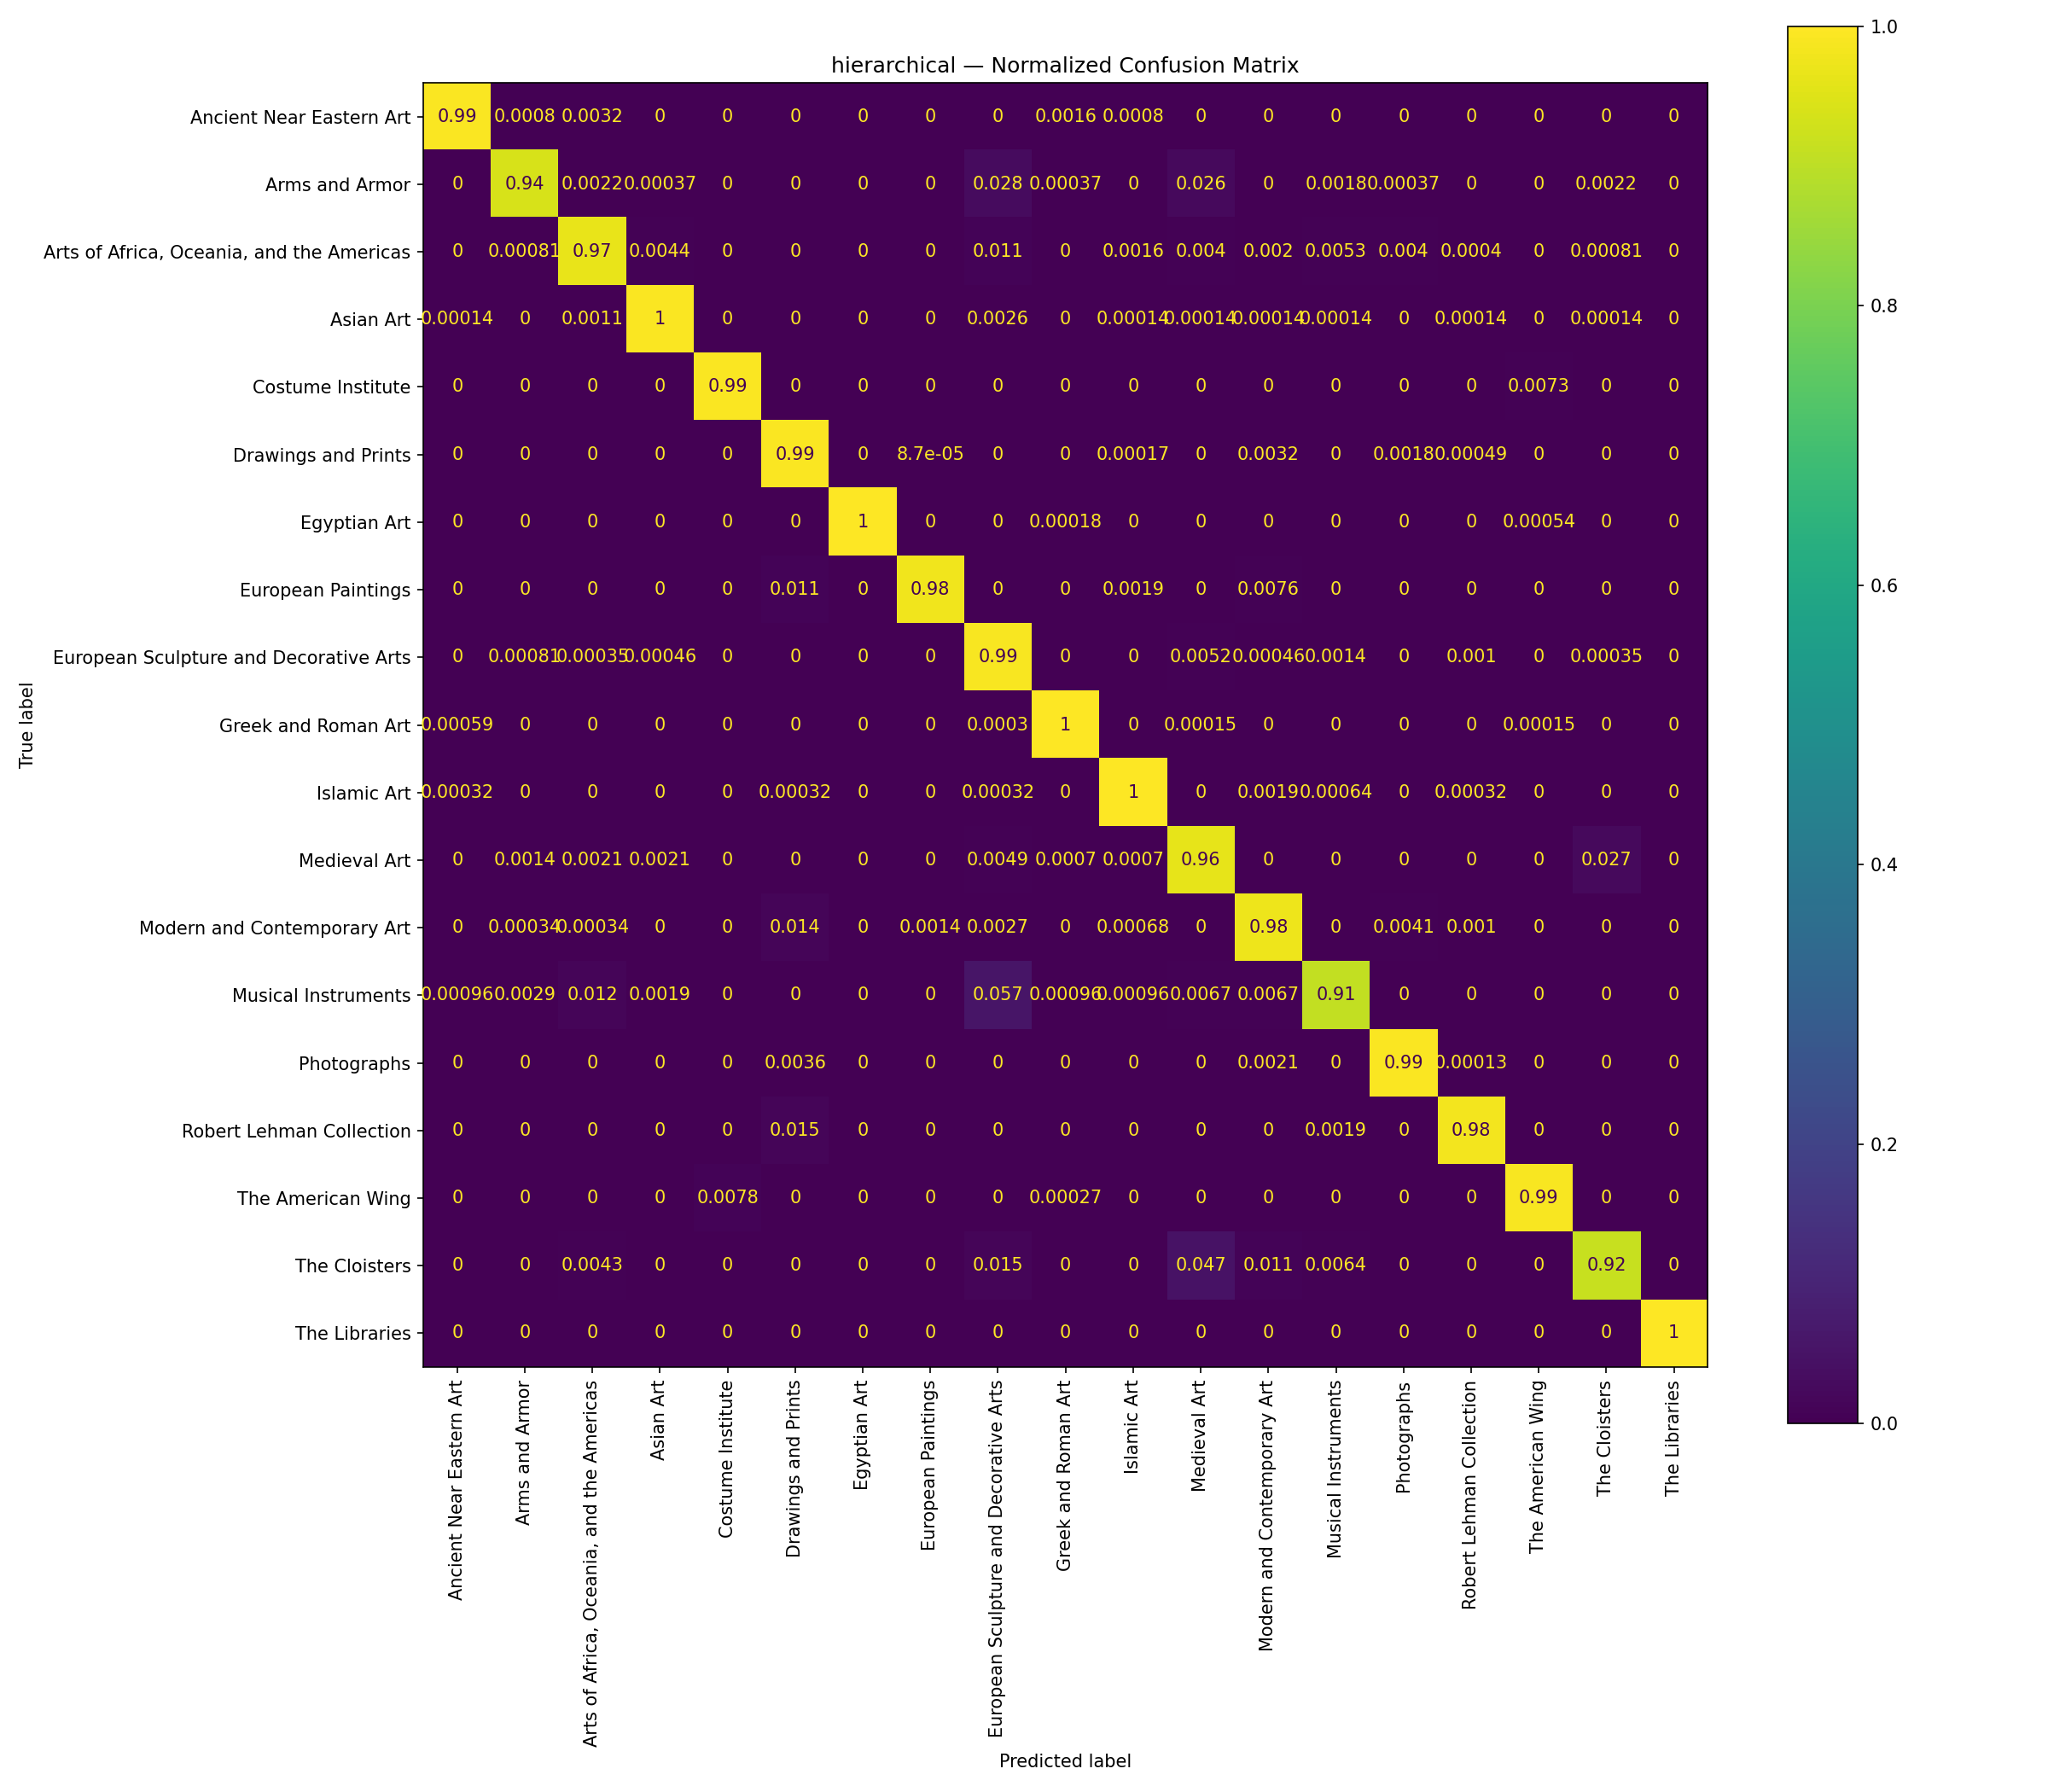

In [10]:
for label, pattern in [
    ('Logistic Regression',                  os.path.join(FIGURES, '*lr*confusion*.png')),
    ('Random Forest',                         os.path.join(FIGURES, '*rf*confusion*.png')),
    ('XGBoost',                               os.path.join(FIGURES, '*xgb*confusion*.png')),
    ('MLP',                                   os.path.join(FIGURES, '*mlp*confusion*.png')),
    ('Hierarchical XGBoost',                  os.path.join(FIGURES, '*hierarchical*confusion*.png')),
]:
    path = latest(pattern)
    print(f'\n{label} — {os.path.basename(path)}')
    display(Image(filename=path, width=800))

## 5. Feature Importance and SHAP

RF feature importance (mean decrease in impurity) — rf_feature_importance_20260410_230643.png


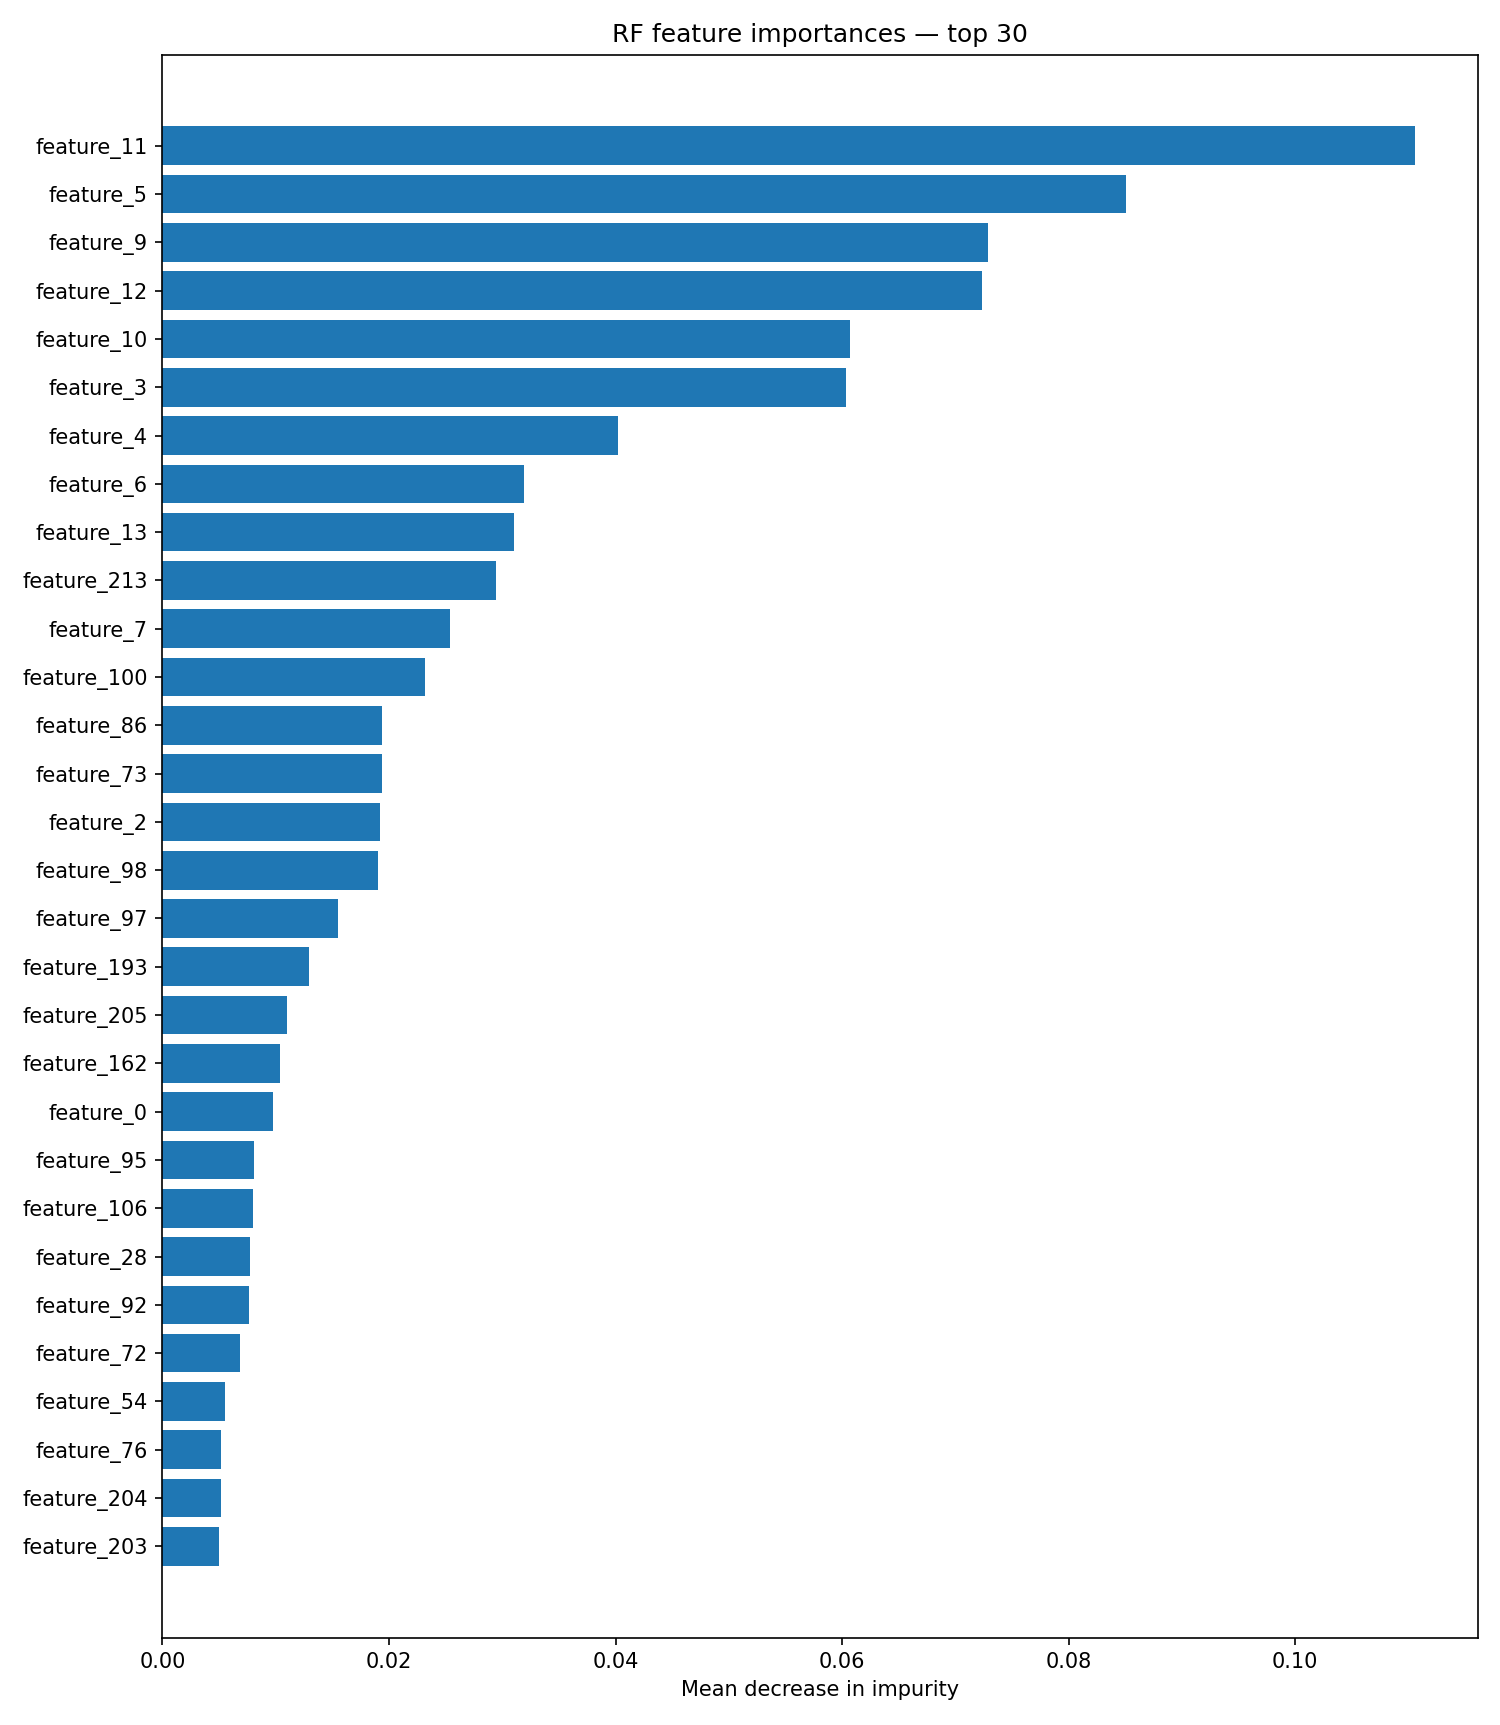

SHAP global importance (mean |SHAP|) — shap_global_importance_20260410_234604.png


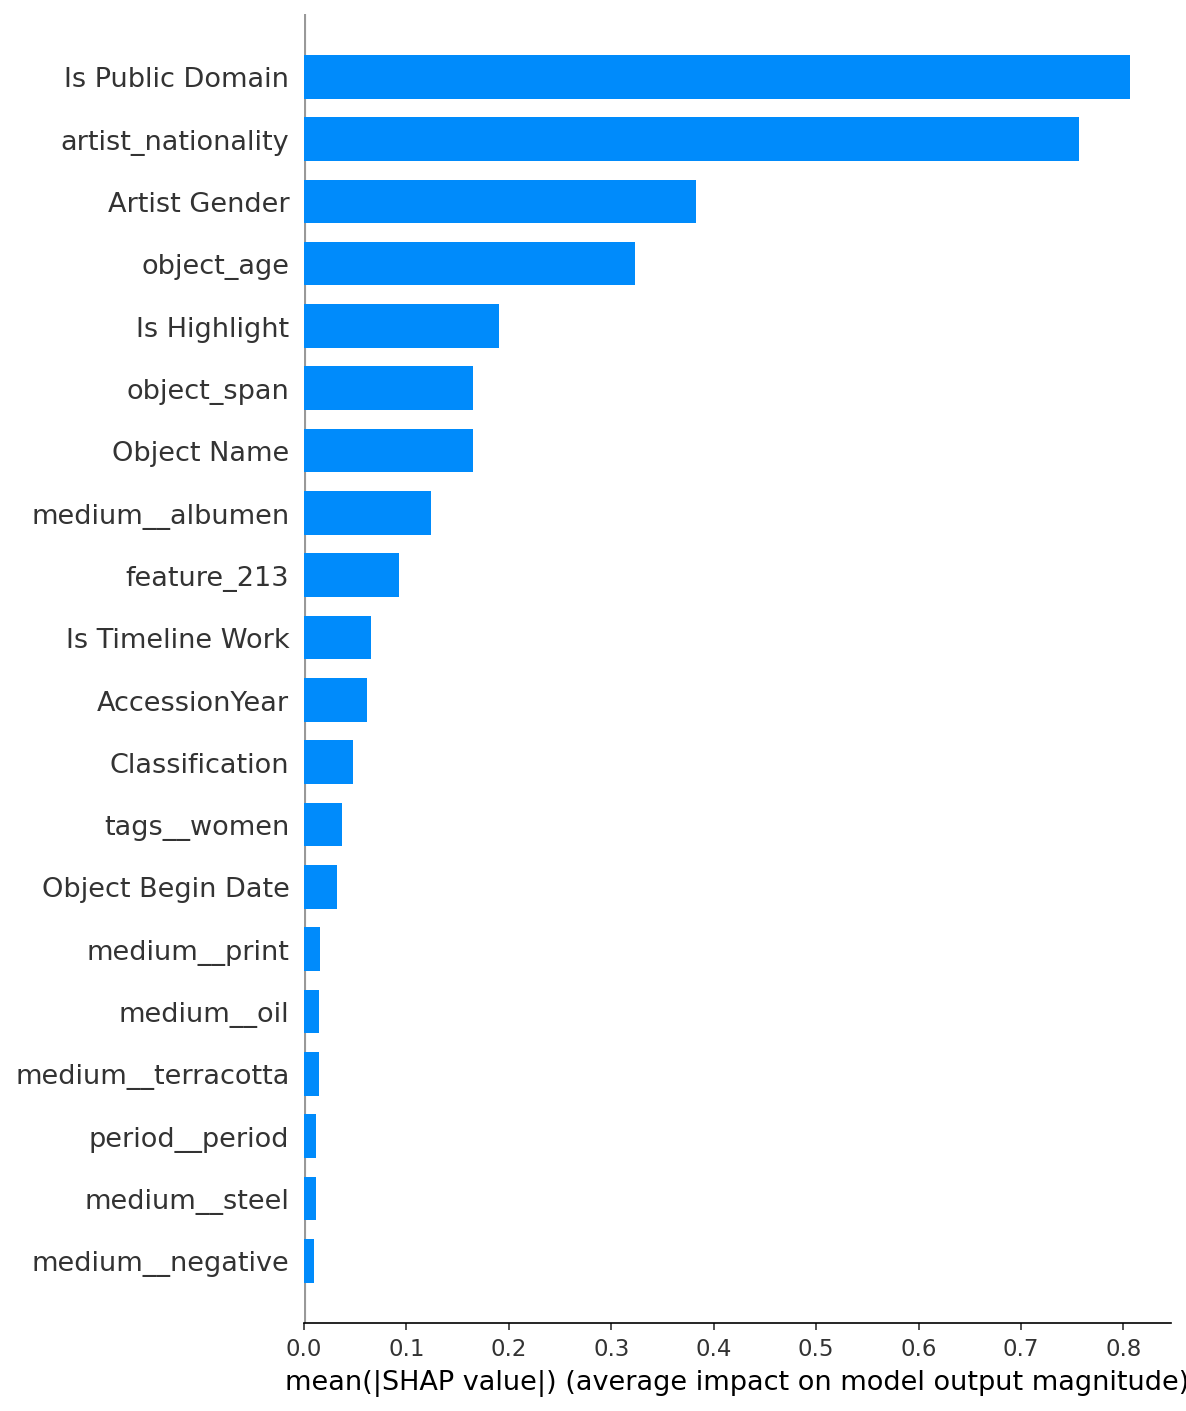


SHAP — worst department: The Cloisters (F1 = 0.85) — shap_worst_the_cloisters_f1_0.85.png


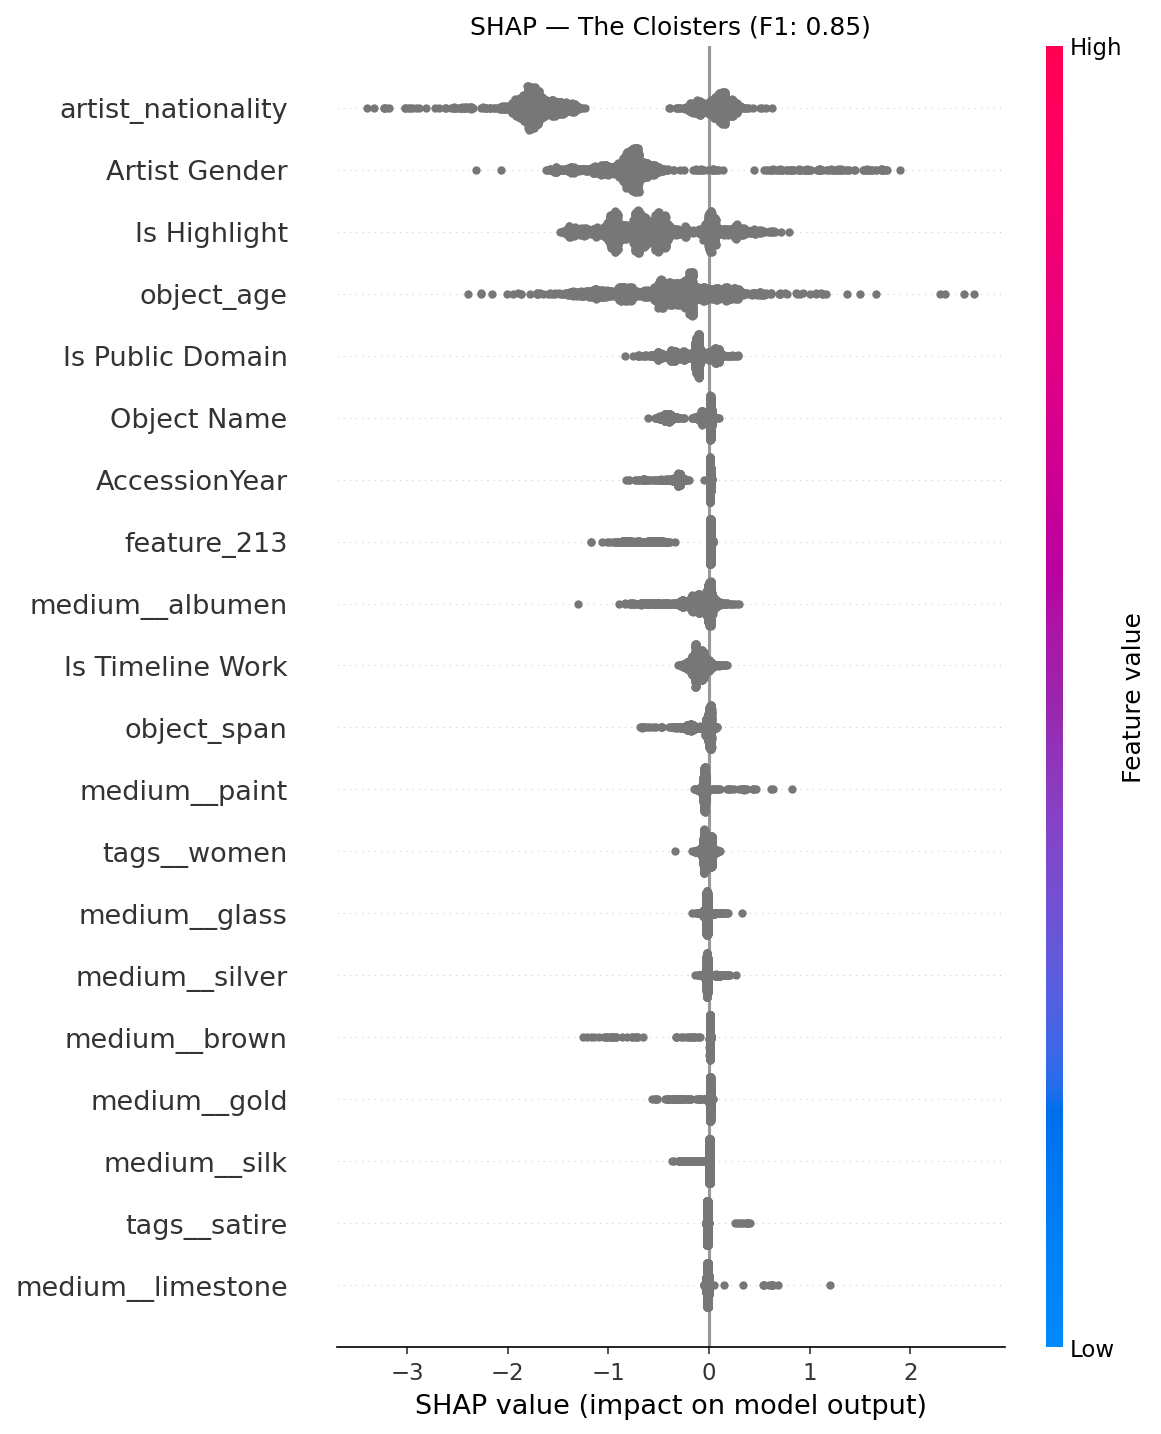


SHAP — mid department: The American Wing (F1 = 0.98) — shap_mid_the_american_wing_f1_0.98.png


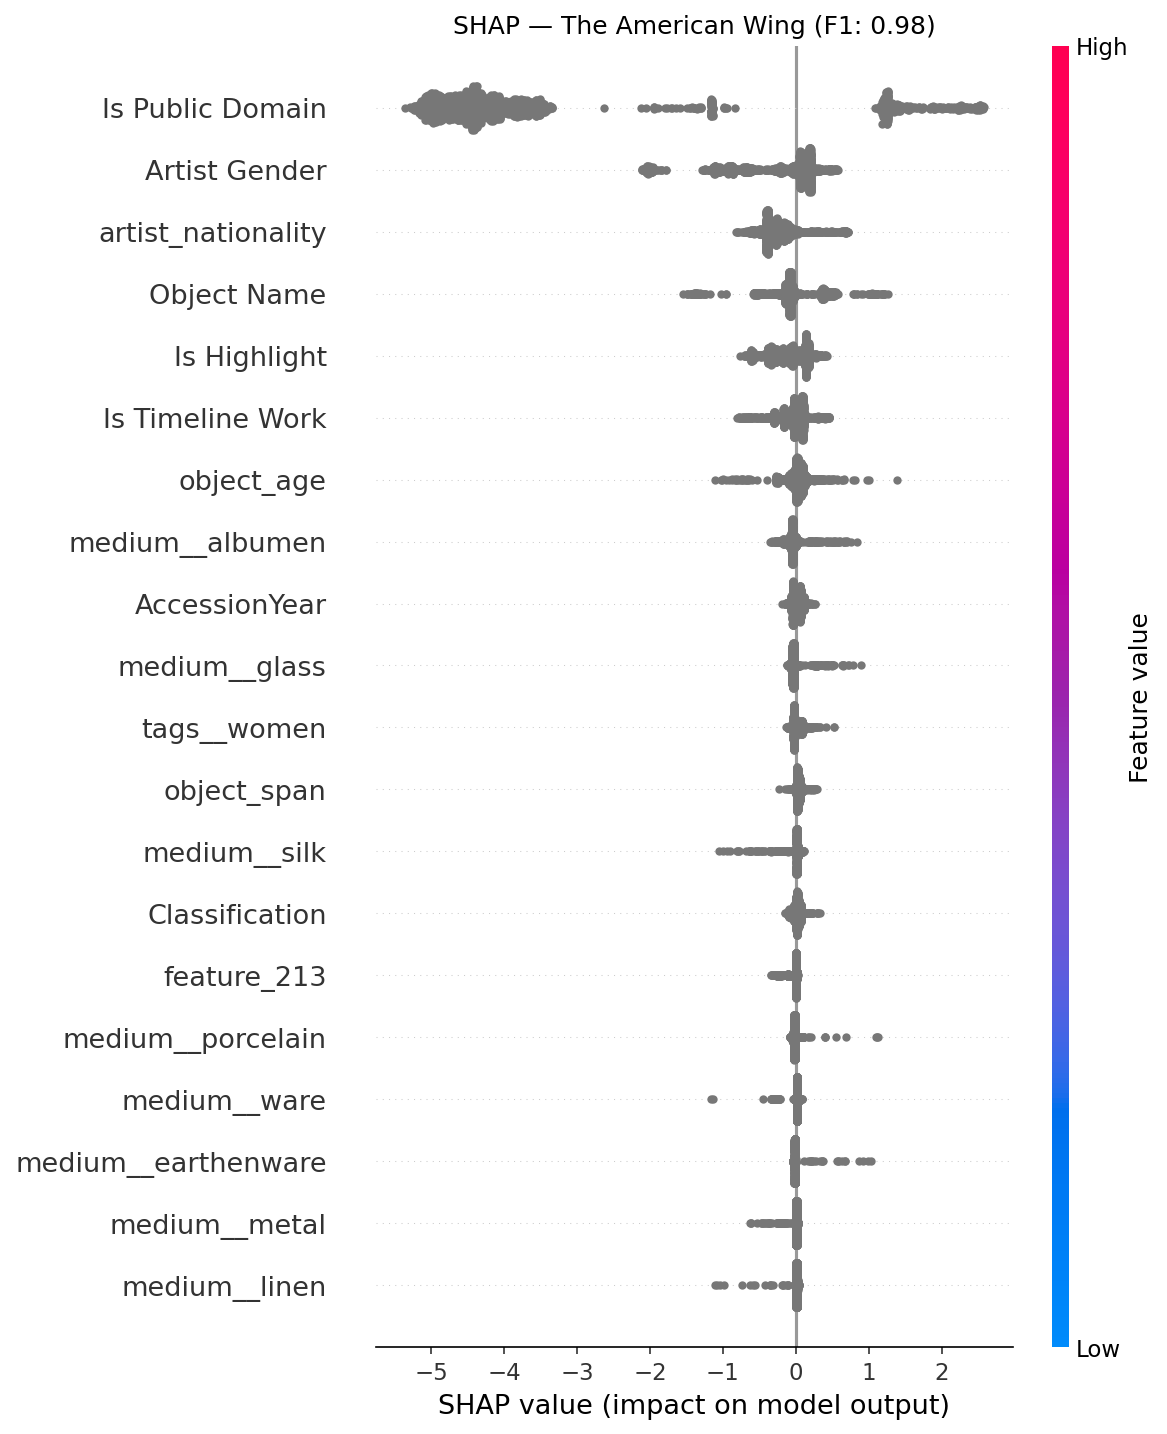


SHAP — best department: The Libraries (F1 = 1.00) — shap_best_the_libraries_f1_1.00.png


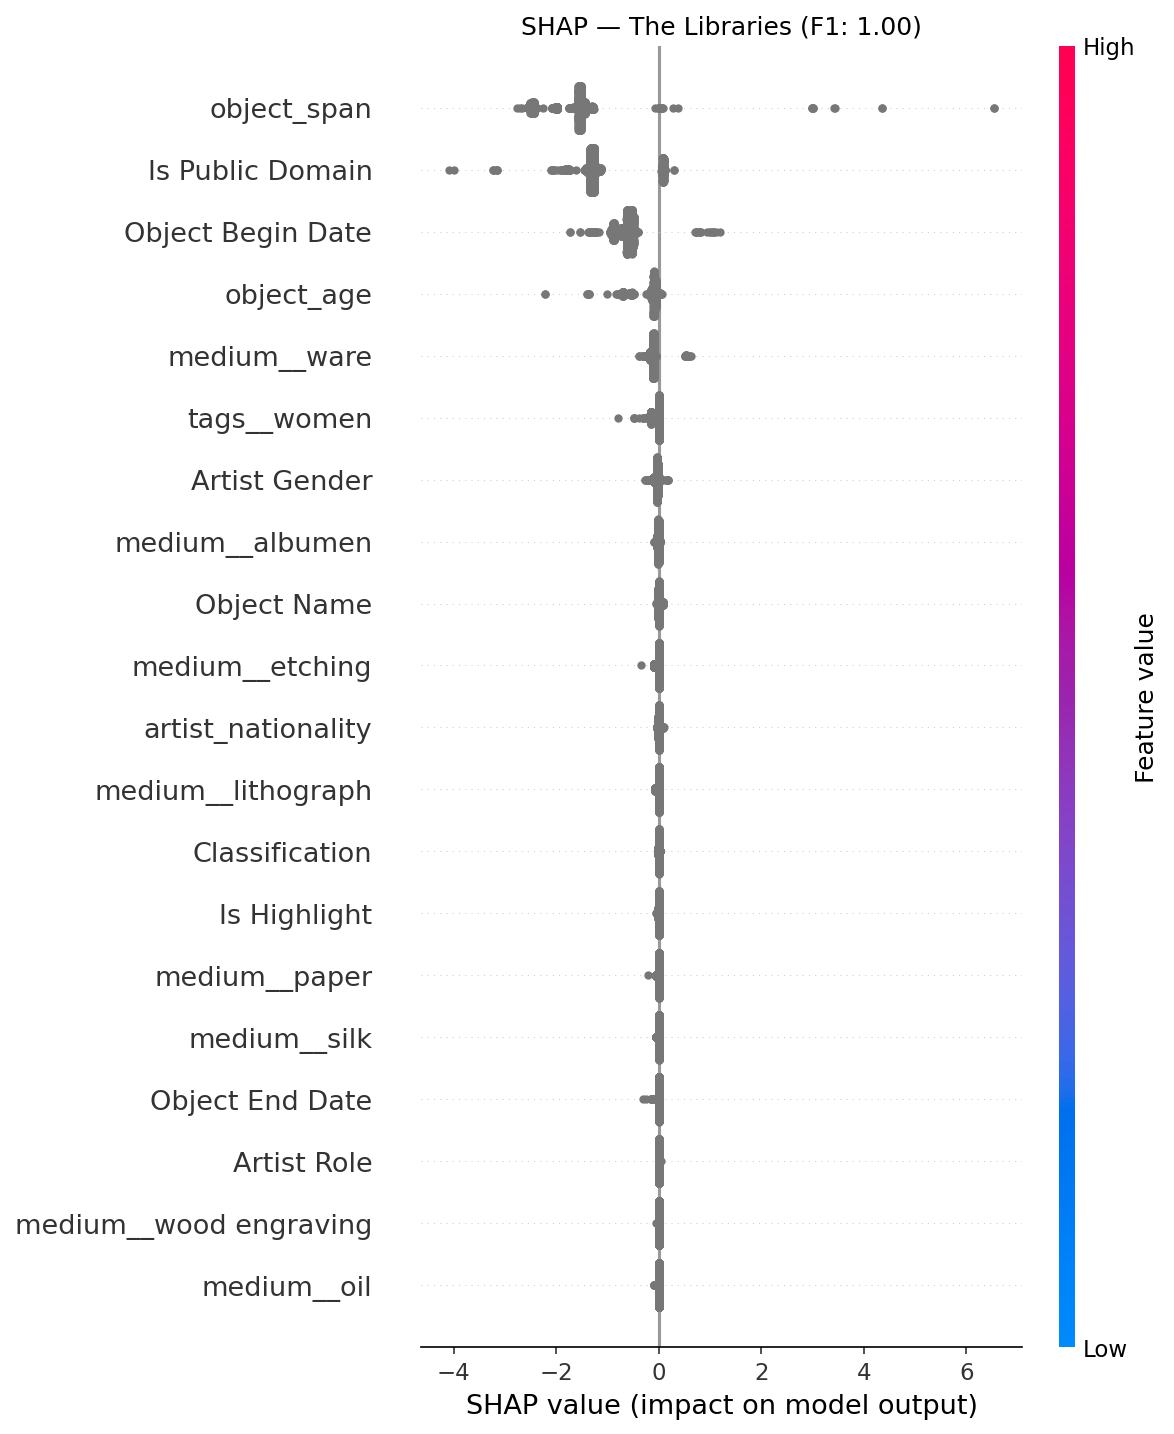

In [11]:
# RF feature importance and SHAP global plot
for label, pattern in [
    ('RF feature importance (mean decrease in impurity)', os.path.join(FIGURES, '*rf*feature*importance*.png')),
    ('SHAP global importance (mean |SHAP|)',               os.path.join(FIGURES, '*shap*global*.png')),
]:
    path = latest(pattern)
    print(f'{label} — {os.path.basename(path)}')
    display(Image(filename=path, width=700))

# Per-class SHAP beeswarms
for label, pattern in [
    ('SHAP — worst department: The Cloisters (F1 = 0.85)',    os.path.join(FIGURES, '*shap*worst*.png')),
    ('SHAP — mid department: The American Wing (F1 = 0.98)',  os.path.join(FIGURES, '*shap*mid*.png')),
    ('SHAP — best department: The Libraries (F1 = 1.00)',     os.path.join(FIGURES, '*shap*best*.png')),
]:
    path = latest(pattern)
    print(f'\n{label} — {os.path.basename(path)}')
    display(Image(filename=path, width=700))

**Interpreting the global SHAP plot.**

`Is Public Domain` is the single most predictive feature globally, outranking all text-based features
by a wide margin.
It acts as a precise era proxy: ancient and classical departments (Ancient Near Eastern, Egyptian,
Greek and Roman) are almost entirely public domain, while Modern and Contemporary Art and Photographs
are not — a single boolean therefore cleanly separates two large macro-regions before any other
feature is consulted.

`artist_nationality` ranks second because the Met's curatorial structure is explicitly geographic:
Asian Art groups by Asian origin, The American Wing by American origin, and so on.
Medium and material descriptions (the TF-IDF features) carry less discriminative signal than expected
because the same material appears across multiple departments — oil on canvas spans European Paintings,
The American Wing, and Modern Art — while nationality resolves the ambiguity directly.

The dominance of these two structured fields over free-text features confirms that the Met's
organizational logic is primarily grounded in era and provenance, not in what objects are made of.

## 6. Hierarchical Model Breakdown

In [12]:
hier_breakdown = pd.DataFrame({
    'Group':           ['Ancient', 'Asian', 'European', 'American', 'Modern', 'Specialized'],
    'Samples':         [13584, 7400, 11548, 3814, 16762, 43884],
    'Stage 1 Acc':     [0.9990, 0.9954, 0.9939, 0.9921, 0.9921, 0.9886],
    'Stage 2 Macro F1':[0.9988, 1.0000, 0.9731, 1.0000, 0.9975, 0.9923],
}).set_index('Group')
display(hier_breakdown)

,Samples,Stage 1 Acc,Stage 2 Macro F1
Group,,,
Ancient,13584,0.9990,0.9988
Asian,7400,0.9954,1.0000
European,11548,0.9939,0.9731
American,3814,0.9921,1.0000
Modern,16762,0.9921,0.9975
Specialized,43884,0.9886,0.9923


**Why European is the hardest group (Stage 2 Macro F1 = 0.973).**

The Cloisters and Medieval Art both cover medieval European material — the same century, the same
geography, the same materials.
Robert Lehman Collection spans paintings and decorative arts that overlap heavily with European
Paintings and European Sculpture.
No metadata field encodes the provenance distinction that curators use to assign objects to one
sub-collection over another: a 14th-century French ivory tapestry is structurally indistinguishable
in metadata from one in The Cloisters.

**What the two-stage architecture solved.**

The flat XGBoost model assigned The Cloisters an F1 of 0.854, the lowest of all 19 departments.
By routing all European samples to a specialist trained exclusively on that sub-problem, the
hierarchical model raised The Cloisters to F1 = 0.906.
The specialist could focus its capacity on the Medieval Art / Cloisters boundary — a signal that
was drowned out in the 19-class setting by the much louder inter-group variation (e.g., Asian Art
vs. Egyptian Art) that the stage 1 classifier now handles upstream.

## 7. Key Findings

**Best model:** Hierarchical XGBoost — Macro F1: 0.976

---

**Model progression:**

| Model | Macro F1 | Why it improved (or didn't) |
|---|---|---|
| Logistic Regression | 0.400 | Baseline; sparse high-dimensional features make linear separation hard |
| Random Forest | 0.867 | Tree ensembles handle sparsity and imbalance far better than LR |
| XGBoost | 0.964 | Sequential error-correction on hard examples; GPU-ready |
| MLP | 0.589 | Sparse tabular data with imbalance does not suit dense neural networks |
| Hierarchical XGBoost | 0.976 | Domain knowledge as model structure beats raw model complexity |

---

**Most important features (from SHAP):**
`Is Public Domain` and `artist_nationality` dominate — era and provenance beat materials as the
primary signal for departmental classification.

---

**The neural network finding:**
MLP scored 0.589 — worse than Random Forest.
Sparse tabular data with class imbalance does not suit neural networks.
Gradient boosting handles sparsity and imbalance more robustly.
This confirms the project thesis that classical ML is the right tool for structured museum metadata.

---

**The hierarchical finding:**
Two-stage classification improved The Cloisters from 0.854 to 0.906 and overall macro F1 from
0.964 to 0.976.
Domain knowledge encoded as model structure outperformed raw model complexity (MLP).

---

**Irreducible confusion:**
The Cloisters (0.906) and Medieval Art (0.928) remain the hardest pair.
Both departments share medieval European vocabulary, similar object ages, and overlapping materials.
This is the honest ceiling of metadata-only classification — image features would likely resolve
the remaining confusion.

---

**One surprising finding:**
`Is Public Domain` — a simple boolean flag — is the single most predictive feature globally.
It acts as a proxy for era, cleanly separating ancient and classical departments (entirely public
domain) from modern ones.
No text feature, date field, or material description matched its discriminative power.